# Module 08 Lab - The Bias-Variance Tradeoff**Objective:** To understand and visualize the concepts of **overfitting**, **underfitting**, and the **bias-variance tradeoff**, which are central to building models that generalize well to new data.**In this lab, you will train models of varying complexity and plot their performance to see these concepts in action.**

## Part 1: Understanding the Concepts*   **Underfitting (High Bias):** The model is **too simple** and fails to capture the underlying patterns in the data. It performs poorly on both the training data and the test data. It has high bias because it makes strong, incorrect assumptions about the data.*   **Overfitting (High Variance):** The model is **too complex** and learns the training data too well, including the noise and random fluctuations. It performs exceptionally well on the training data but poorly on the test data because it has memorized the training set instead of learning the general pattern. It has high variance because its performance changes drastically with different training data.*   **The Goal:** Find a model that is "just right"—complex enough to capture the true pattern but not so complex that it memorizes the noise. This is the **bias-variance tradeoff**.

## Part 2: SetupTo visualize this, we will create a synthetic (fake) dataset with a known pattern and some noise.

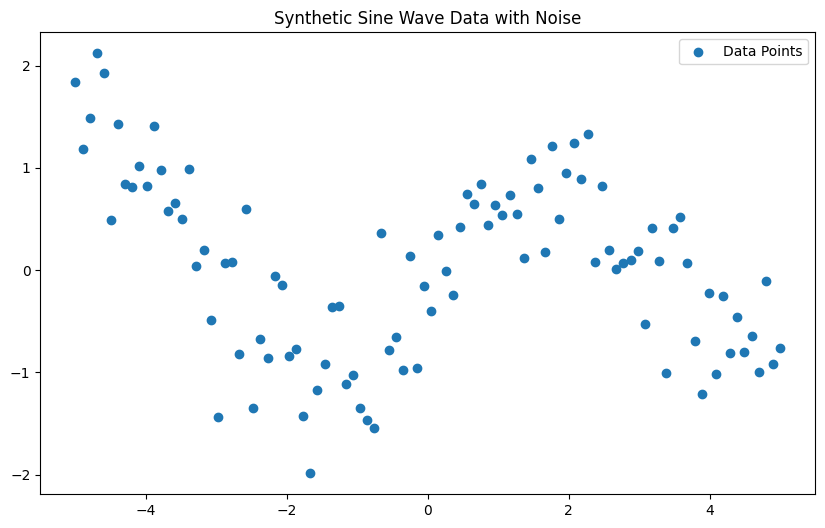

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
# Generate some synthetic data
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = np.sin(X) + np.random.normal(0, 0.5, 100)
X = X[:, np.newaxis]
# Plot the data to see the underlying sine wave pattern
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data Points')
plt.title('Synthetic Sine Wave Data with Noise')
plt.legend()
plt.show()

## Part 3: Modeling with Different ComplexitiesWe will use **Polynomial Regression** to control model complexity. A polynomial of degree 1 is a simple straight line (underfitting). A polynomial of degree 15 is a very complex, wiggly line (overfitting).**Your Task:** Train and visualize three models with different degrees (1, 4, and 15) to see underfitting, a good fit, and overfitting.

### Task 1: Train and Plot Models**Your Task:** For each degree (1, 4, 15), create a polynomial regression model, train it, and plot its predictions against the original data.

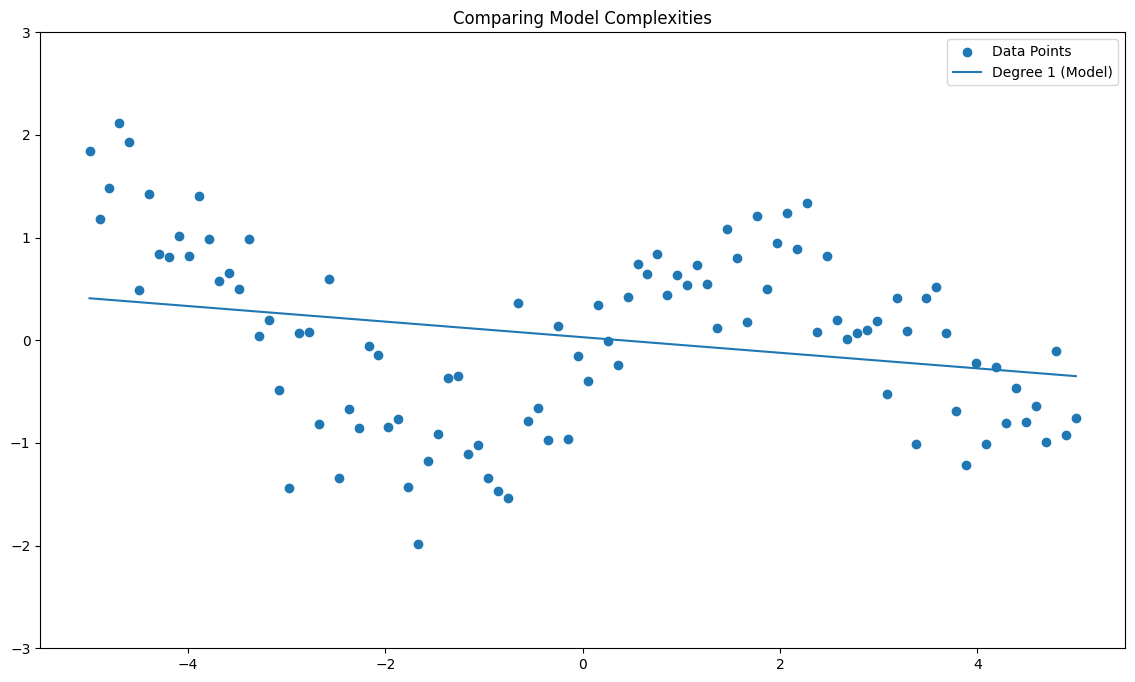

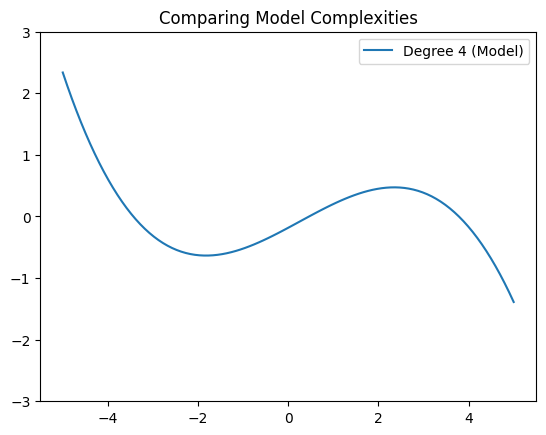

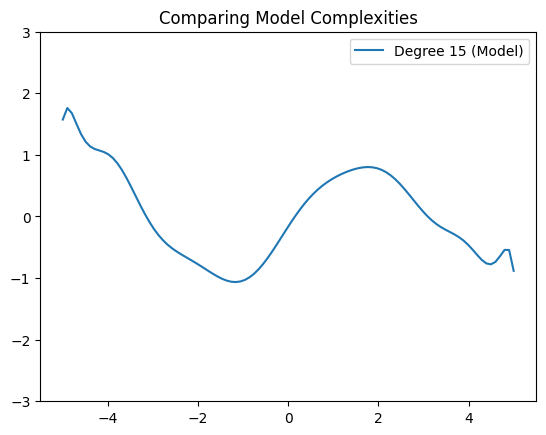

In [3]:
# --- ENTER YOUR CODE HERE ---
plt.figure(figsize=(14, 8))
plt.scatter(X, y, label='Data Points')
degrees = [1, 4, 15]
for degree in degrees:
  # 1. Create a pipeline that adds polynomial features and then fits a linear regression model    #
  model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
  # 2. Train the model    #
  model.fit(X, y)
  # 3. Make predictions    #
  y_pred = model.predict(X)
  # 4. Plot the model's predictions    #
  plt.plot(X, y_pred, label=f'Degree {degree} (Model)')
  plt.legend()
  plt.title('Comparing Model Complexities')
  plt.ylim(-3, 3)
  plt.show()

## Part 4: Learning Curves**Concept:** A **learning curve** is a powerful tool to diagnose bias and variance. It plots the model's performance (e.g., accuracy or error) on both the **training set** and the **validation set** as a function of the number of training samples.*   **High Bias (Underfitting):** Both the training score and validation score will be low and will plateau quickly. The model is too simple to learn from more data.*   **High Variance (Overfitting):** There will be a large gap between the high training score and the low validation score. The model memorized the training data but can't generalize.*   **Just Right:** The training and validation scores will converge to a high value.

### Task 2: Plot Learning Curves**Your Task:** Use the `learning_curve` function from scikit-learn to plot the learning curves for the underfit (degree 1) and overfit (degree 15) models.

In [4]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
  plt.figure(figsize=(10,6))
  plt.title(title)
  if ylim is not None:
    plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes
        )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r"
                     )
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g"
                     )
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    return plt
    # --- ENTER YOUR CODE HERE ---
    # 1. Create the underfit and overfit models#
    underfit_model = make_pipeline(PolynomialFeatures(1), LinearRegression())#
    overfit_model = make_pipeline(PolynomialFeatures(15), LinearRegression())
    # 2. Plot the learning curve for the underfit model#
    plot_learning_curve(underfit_model, "Learning Curve (Underfitting, Degree 1)", X, y, cv=5)#
    plt.show()
    # 3. Plot the learning curve for the overfit model#
    plot_learning_curve(overfit_model, "Learning Curve (Overfitting, Degree 15)", X, y, cv=5)#
    plt.show()

## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.
1.  **In the first plot of the three models, which model (degree 1, 4, or 15) is underfitting, which is overfitting, and which is a good fit? Explain your reasoning.**
2.  **Looking at the learning curve for the underfitting model, what do you observe about the training and cross-validation scores?** What does this tell you?
3.  **Looking at the learning curve for the overfitting model, what do you observe about the gap between the training and cross-validation scores?** What does this tell you?

**[ENTER YOUR ANSWERS HERE]**

1.  
* The degree 1 model is underfitting. A straight line simply can't capture a sine wave pattern. It misses the curves on both ends and through the middle, performing poorly on training data and test data alike. That's the hallmark of high bias: the model's assumptions are too rigid for the actual shape of the data.
* The degree 15 model is overfitting. Its prediction line chases every noisy data point, producing wild swings at the edges of the plot. It fits the training data almost perfectly, but those extreme wiggles don't reflect the true underlying sine wave; they reflect noise. That's high variance: the model memorized the training set instead of learning the pattern.
* The degree 4 model is the good fit. Its curve follows the general sine wave shape without overreacting to individual noisy points. It captures the real pattern while ignoring the random fluctuations, which is exactly what a well-generalized model should do.

2. Both the training score and the cross-validation score are low, and they converge to each other relatively quickly as more training data is added. The key observation is that adding more data doesn't help — the gap between the two curves is small, but both scores are stuck at a low ceiling. This tells us the problem isn't a lack of data; it's that the model itself is too simple. No amount of additional training examples will allow a straight line to fit a sine wave well.

3. The training score stays very high while the cross-validation score remains significantly lower, creating a large persistent gap between the two curves. This gap is the signature of high variance — the model performs well on data it has seen but fails to generalize to new data. Unlike the underfitting case, adding more training examples does help narrow the gap somewhat, but slowly. The model is too complex relative to the amount of data available, so it picks up noise as if it were signal.